In [2]:
import pandas as pd
import numpy as np

In [3]:

temp_data = np.load('embeddingsbert_embeddings.npy', allow_pickle=True)
print(temp_data.shape)

(26298, 384)


In [4]:

embeddings_data = np.load('embeddingsbert_embeddings.npy')

In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=150, random_state=42)

X_pca = pca.fit_transform(embeddings_data)

explained_variance = sum(pca.explained_variance_ratio_) * 100

print(f"the real Dim {embeddings_data.shape[1]}")
print(f"the new dim after compression: {X_pca.shape[1]}")
print(f"the model keep {explained_variance:.2f}% from the real info")


the real Dim 384
the new dim after compression: 150
the model keep 86.83% from the real info


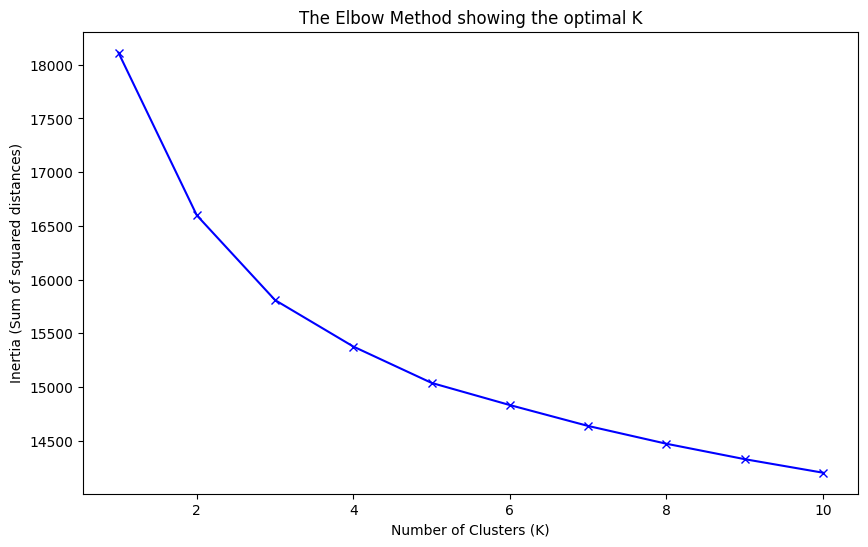

Elbow Method execution completed. Please check the plot to find the 'elbow' point.


In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as p
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)


plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Sum of squared distances)')
plt.title('The Elbow Method showing the optimal K')
plt.show()

print("Elbow Method execution completed. Please check the plot to find the 'elbow' point.")


In [7]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=7, random_state=42)

gmm_clusters = gmm.fit_predict(X_pca)

print("GMM Clustering with 7 components is completed.")

import numpy as np
unique, counts = np.unique(gmm_clusters, return_counts=True)
print("Points per cluster:", dict(zip(unique, counts)))


GMM Clustering with 7 components is completed.
Points per cluster: {np.int64(0): np.int64(4399), np.int64(1): np.int64(3663), np.int64(2): np.int64(2062), np.int64(3): np.int64(4866), np.int64(4): np.int64(3226), np.int64(5): np.int64(5703), np.int64(6): np.int64(2379)}


In [9]:
labeled=pd.read_csv("encodeing_label.csv")

In [10]:
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()
y = le.fit_transform(labeled['label'])


print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Anxiety': np.int64(0), 'Bipolar': np.int64(1), 'Depression': np.int64(2), 'Normal': np.int64(3), 'Personality_disorder': np.int64(4), 'Stress': np.int64(5), 'Suicidal': np.int64(6)}


In [14]:
labeled['label'].unique()

array(['Bipolar', 'Suicidal', 'Personality_disorder', 'Anxiety',
       'Depression', 'Stress', 'Normal'], dtype=object)

In [17]:
y_labels=labeled['label']

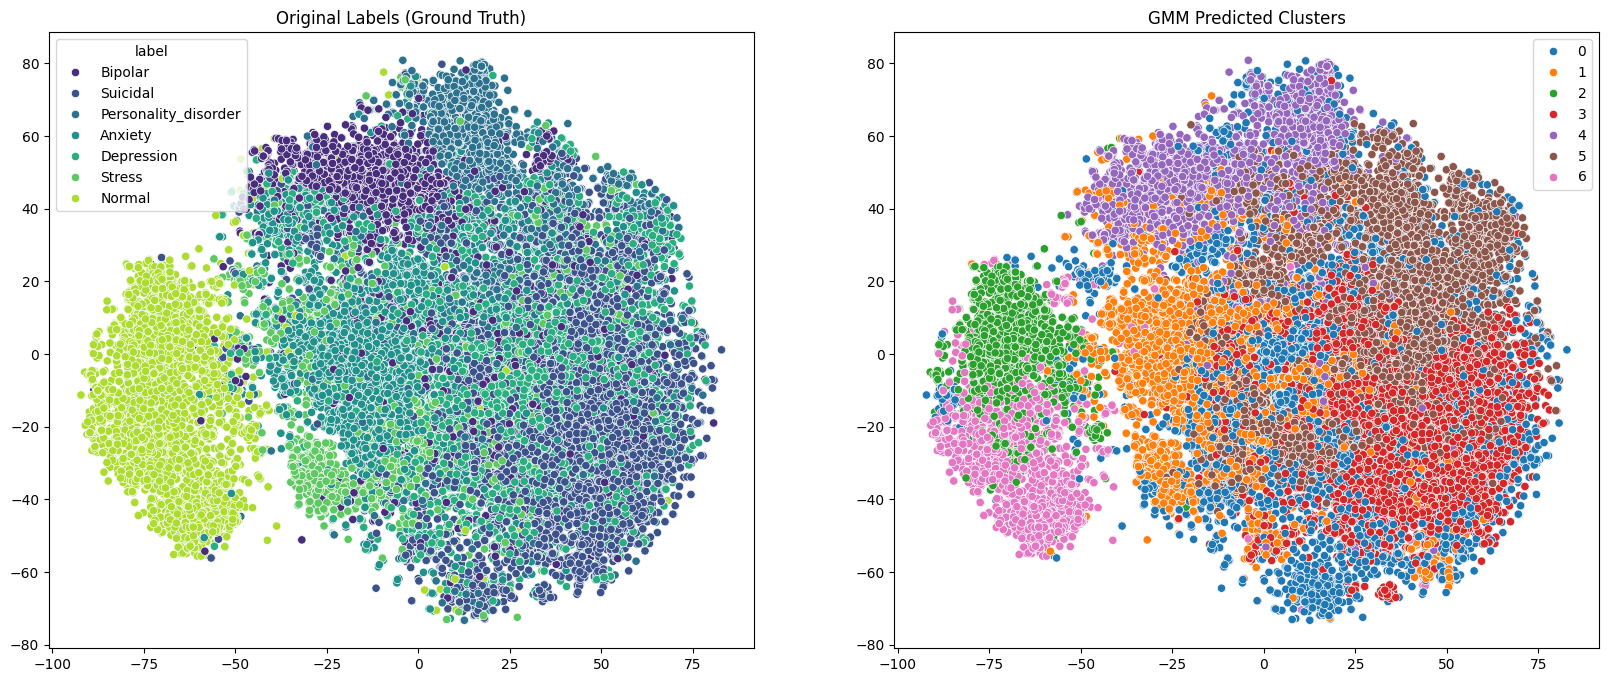

Visualization completed. Compare both plots to see how well the clusters align with labels.


In [18]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

fig, ax = plt.subplots(1, 2, figsize=(20, 8))

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_labels, palette='viridis', ax=ax[0])
ax[0].set_title('Original Labels (Ground Truth)')

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=gmm_clusters, palette='tab10', ax=ax[1])
ax[1].set_title('GMM Predicted Clusters')

plt.show()

print("Visualization completed. Compare both plots to see how well the clusters align with labels.")


Cluster 0 is mostly associated with: Suicidal
Cluster 1 is mostly associated with: Anxiety
Cluster 2 is mostly associated with: Normal
Cluster 3 is mostly associated with: Suicidal
Cluster 4 is mostly associated with: Bipolar
Cluster 5 is mostly associated with: Suicidal
Cluster 6 is mostly associated with: Normal


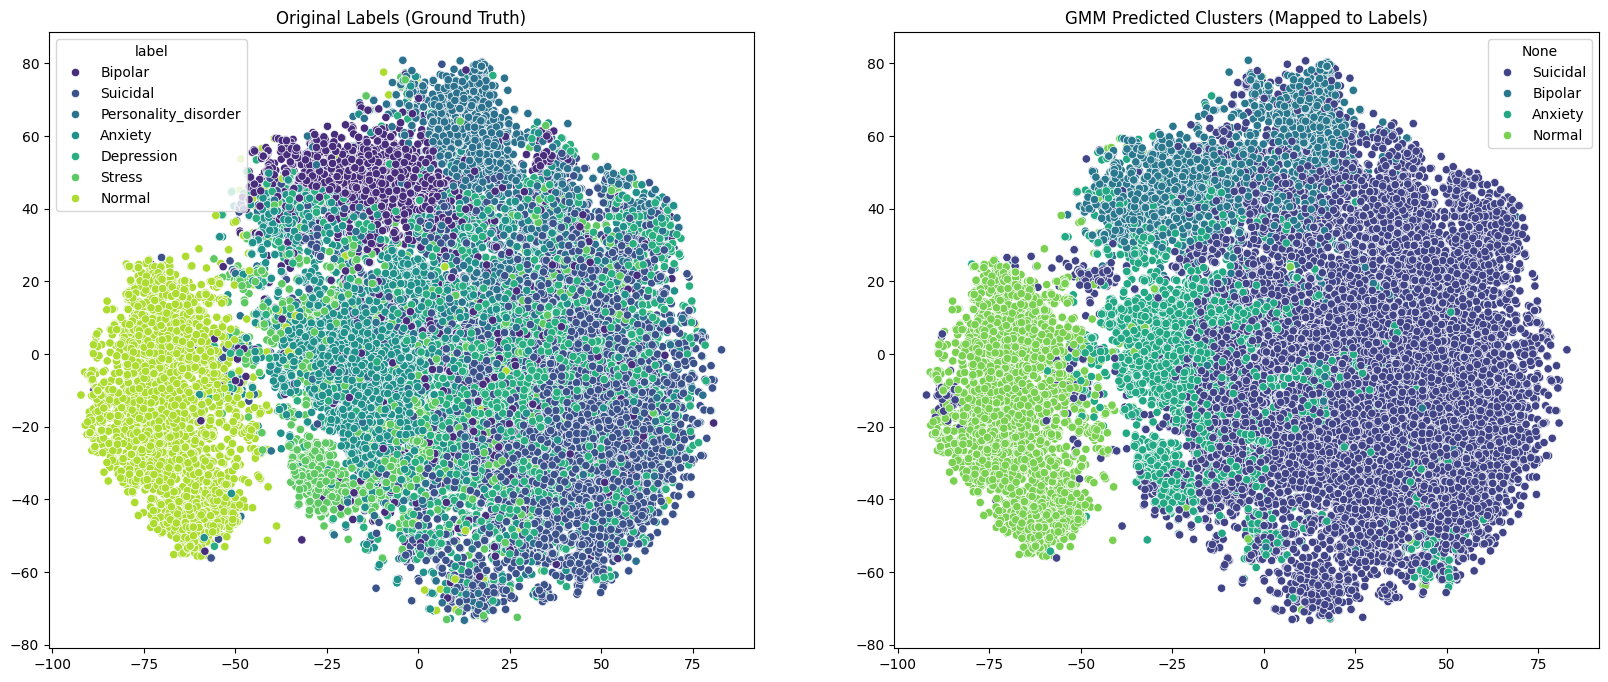

Visualization completed with synchronized colors for direct comparison.


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cluster_map = {}
for i in range(7):
    most_common = labeled[gmm_clusters == i]['label'].mode()[0]
    cluster_map[i] = most_common
    print(f"Cluster {i} is mostly associated with: {most_common}")

gmm_mapped_names = pd.Series(gmm_clusters).map(cluster_map)

fig, ax = plt.subplots(1, 2, figsize=(20, 8))

my_palette = 'viridis'

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_labels, palette=my_palette, ax=ax[0])
ax[0].set_title('Original Labels (Ground Truth)')

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=gmm_mapped_names, palette=my_palette, ax=ax[1])
ax[1].set_title('GMM Predicted Clusters (Mapped to Labels)')

plt.show()

print("Visualization completed with synchronized colors for direct comparison.")

In [23]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_labels, gmm_mapped_names)
print(f"Clustering Accuracy after Mapping: {accuracy*100:.2f}%")

print("\nDetailed Clustering Report:")
print(classification_report(y_labels, gmm_mapped_names))


Clustering Accuracy after Mapping: 47.80%

Detailed Clustering Report:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                      precision    recall  f1-score   support

             Anxiety       0.49      0.38      0.43      4704
             Bipolar       0.40      0.48      0.44      2720
          Depression       0.00      0.00      0.00      4111
              Normal       0.98      0.95      0.96      4574
Personality_disorder       0.00      0.00      0.00      2807
              Stress       0.00      0.00      0.00      1794
            Suicidal       0.34      0.92      0.50      5588

            accuracy                           0.48     26298
           macro avg       0.32      0.39      0.33     26298
        weighted avg       0.37      0.48      0.40     26298



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [24]:
!pip install umap-learn hdbscan


In [26]:
import umap
import hdbscan
from sklearn.metrics import normalized_mutual_info_score


reducer = umap.UMAP(n_neighbors=15, n_components=50, metric='cosine', random_state=42)
X_umap = reducer.fit_transform(embeddings_data)

clusterer = hdbscan.HDBSCAN(min_cluster_size=100, gen_min_span_tree=True)
hdb_clusters = clusterer.fit_predict(X_umap)

nmi = normalized_mutual_info_score(y_labels, hdb_clusters)
print(f"Improved Clustering NMI Score: {nmi:.4f}")


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Improved Clustering NMI Score: 0.3537


 in down The model which we approve ***


In [31]:
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report

reducer = umap.UMAP(n_neighbors=30, n_components=20, metric='cosine', random_state=42)
X_final_features = reducer.fit_transform(embeddings_data)

kmeans_final = KMeans(n_clusters=7, n_init=20, random_state=42)
final_clusters = kmeans_final.fit_predict(X_final_features)

cluster_map = {}
for i in range(7):
    mask = (final_clusters == i)
    if mask.any():
        most_common = labeled.loc[mask, 'label'].mode()[0]
        cluster_map[i] = most_common

mapped_predictions = [cluster_map[c] for c in final_clusters]

print(f"Final Clustering Accuracy: {accuracy_score(y_labels, mapped_predictions)*100:.2f}%")
print("\nFinal Classification Report:")
print(classification_report(y_labels, mapped_predictions))


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Final Clustering Accuracy: 60.21%

Final Classification Report:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                      precision    recall  f1-score   support

             Anxiety       0.61      0.59      0.60      4704
             Bipolar       0.65      0.52      0.58      2720
          Depression       0.37      0.46      0.41      4111
              Normal       0.98      0.98      0.98      4574
Personality_disorder       0.74      0.46      0.57      2807
              Stress       0.00      0.00      0.00      1794
            Suicidal       0.50      0.71      0.58      5588

            accuracy                           0.60     26298
           macro avg       0.55      0.53      0.53     26298
        weighted avg       0.59      0.60      0.59     26298



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [38]:
print(labeled.columns)


Index(['label'], dtype='object')


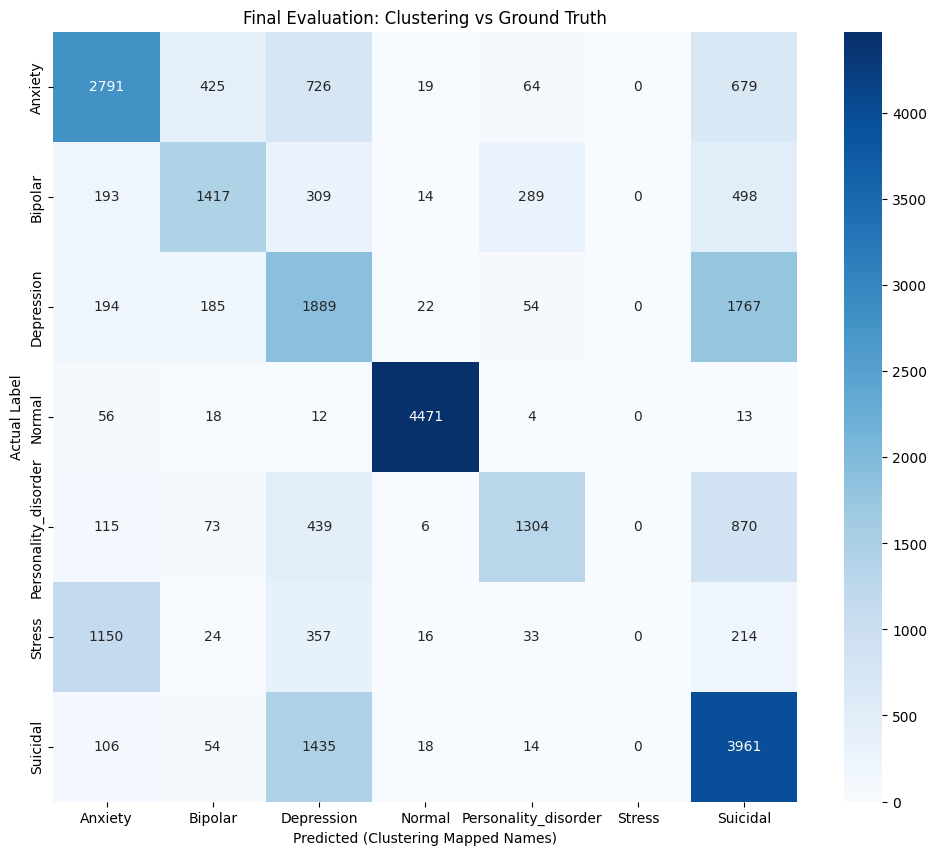

Evaluation completed. This matrix shows how well the clustering discovered the actual mental health categories.


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

cm = confusion_matrix(y_labels, mapped_predictions)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_labels),
            yticklabels=np.unique(y_labels))

plt.title('Final Evaluation: Clustering vs Ground Truth')
plt.xlabel('Predicted (Clustering Mapped Names)')
plt.ylabel('Actual Label')
plt.show()

print("Evaluation completed. This matrix shows how well the clustering discovered the actual mental health categories.")


In [40]:
import joblib

joblib.dump(reducer, 'umap_reducer.joblib')
joblib.dump(kmeans_final, 'kmeans_model.joblib')
joblib.dump(cluster_map, 'cluster_mapping.joblib')

print("Clustering models saved successfully as .joblib files!")


Clustering models saved successfully as .joblib files!


In [41]:
import joblib
import numpy as np

def predict_from_clustering(new_embedding):
    """
    Input: new_embedding (numpy array of shape (1, 384))
    Output: Mental health category name
    """
    # 1. Load the saved components
    loaded_reducer = joblib.load('umap_reducer.joblib')
    loaded_kmeans = joblib.load('kmeans_model.joblib')
    loaded_map = joblib.load('cluster_mapping.joblib')

    # 2. Transform the new embedding using UMAP
    # This compresses the input from 384 to 20 dimensions
    compressed_input = loaded_reducer.transform(new_embedding)

    # 3. Predict the Cluster ID
    cluster_id = loaded_kmeans.predict(compressed_input)[0]

    # 4. Get the mapped label name
    predicted_label = loaded_map[cluster_id]

    return predicted_label

# --- Example of how to use it ---
# Assuming 'sample_input' is a BERT embedding for a new sentence
# prediction = predict_from_clustering(sample_input.reshape(1, -1))
# print(f"Predicted Category: {prediction}")


In [42]:

sample_input = embeddings_data[0].reshape(1, -1)
result = predict_from_clustering(sample_input)

print(f"--- Inference Results ---")
print(f"The Predicted Category is: {result}")


--- Inference Results ---
The Predicted Category is: Suicidal
